In [1]:
from tqdm import tqdm
from multiprocess import Pool
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from mass_flux_dist import *
from linear_flux import *
import cmcrameri.cm as cmc
import os

In [2]:
params={     
    'axes.labelsize'  : '14',   
    'axes.titlesize'  : '14',  
    'xtick.labelsize' :'14',
    'ytick.labelsize' :'14',    
    'lines.linewidth' : '2' ,   
    'legend.fontsize' : '12', 
    'figure.figsize'   : '12, 7'    
}
plt.rcParams.update(params)

In [3]:

def scatter_to_contour(x_in,y_in,z_in):
    # 1D scattered data
    x = np.asarray(x_in)
    y = np.asarray(y_in)
    z = np.asarray(z_in)

    # make regular grid
    xi = np.linspace(x.min(), x.max(), 100)
    yi = np.linspace(y.min(), y.max(), 100)
    Xi, Yi = np.meshgrid(xi, yi)

    # interpolate scattered data onto grid
    Zi = griddata((x, y), z, (Xi, Yi), method="linear")
    return Xi, Yi, Zi

In [4]:
def get_Palmer_plane_skew(z_b=1400,mprofile="cos",skew_type = "left", read_from_file=False):
    
    fname = f"Data/LCL_ext_{z_b}m_mprof-{mprofile}_skew-{skew_type}.csv"

    if os.path.exists(fname) & read_from_file:
       df = pd.read_csv(fname)
       return df

    # 1. Create (RH, P) pairs

    ## Use sequences
    #RH_values = np.linspace(0.01, 0.99, 50)
    #P_values = np.linspace(0, 20, 30)

    RH_values = np.linspace(0.02, 0.98, 25)
    P_values = np.linspace(0, 30, 31)


    param_pairs = [(RH, P) for RH in RH_values for P in P_values]

    # 2. Define worker function
    def worker(args):
        RH, P = args
        CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def,dz,ent_b = spectral_plume_skew(
            model_type="precip", RH=RH, P=P, z_lcl=z_b,mprofile=mprofile,
            get_plane=True, plotting=False, save_data=False,skew_type = skew_type
        )
        return CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def, P, RH,dz,ent_b

    # 3. Run in parallel
    num_cpus = 4
    with Pool(processes=num_cpus) as pool:
        results = list(tqdm(pool.imap(worker, param_pairs), total=len(param_pairs)))


    # 4. Unpack results
    CAPEu_list, CAPEext_list, CAPEdist_list, dh_list, sat_def_list, P_list,RH_list,dz_list,ent_b_list = zip(*results)
    CAPEu_list = list(CAPEu_list)
    CAPEext_list = list(CAPEext_list)
    CAPEdist_list = list(CAPEdist_list)
    dh_list = list(dh_list)
    sat_def_list = list(sat_def_list)
    P_list = list(P_list)
    RH_list = list(RH_list)
    dz_list = list(dz_list)
    ent_b_list = list(ent_b_list)

    # 5. Save to CSV
    df = pd.DataFrame({
        "CAPE_u":CAPEu_list,
        "CAPE_ext": CAPEext_list,
        "CAPE_dist": CAPEdist_list,
        "dh": dh_list,
        "sat_def": sat_def_list,
        "P": P_list,
        "RH": RH_list,
        "dz": dz_list,
        "ent_b":ent_b_list
                })
    df.to_csv(fname, index=False)

    return df

def get_Palmer_plane_linear(z_b=1400,mprofile="cos",skew_type = "linear-increase", read_from_file=False):
    
    fname = f"Data/LCL_ext_{z_b}m_mprof-{mprofile}_{skew_type}.csv"

    if os.path.exists(fname) & read_from_file:
       df = pd.read_csv(fname)
       return df

    # 1. Create (RH, P) pairs

    ## Use sequences
    #RH_values = np.linspace(0.01, 0.99, 50)
    #P_values = np.linspace(0, 20, 30)

    RH_values = np.linspace(0.02, 0.98, 25)
    P_values = np.linspace(0, 30, 31)


    param_pairs = [(RH, P) for RH in RH_values for P in P_values]

    # 2. Define worker function
    def worker(args):
        RH, P = args
        CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def,dz,ent_b,ent_spec, a, b = spectral_plume_linear(
            model_type="precip", RH=RH, P=P, z_lcl=z_b,mprofile=mprofile,
            get_plane=True, plotting=False, save_data=False,skew_type = skew_type
        )
        return CAPE_u, CAPE_ext, CAPE_dist, dh, sat_def, P, RH,dz,ent_b,ent_spec, a, b

    # 3. Run in parallel
    num_cpus = 4
    with Pool(processes=num_cpus) as pool:
        results = list(tqdm(pool.imap(worker, param_pairs), total=len(param_pairs)))


    # 4. Unpack results
    CAPEu_list, CAPEext_list, CAPEdist_list, dh_list, sat_def_list, P_list,RH_list,dz_list,ent_b_list,ent_spec_list, a_list, b_list = zip(*results)
    CAPEu_list = list(CAPEu_list)
    CAPEext_list = list(CAPEext_list)
    CAPEdist_list = list(CAPEdist_list)
    dh_list = list(dh_list)
    sat_def_list = list(sat_def_list)
    P_list = list(P_list)
    RH_list = list(RH_list)
    dz_list = list(dz_list)
    ent_b_list = list(ent_b_list)
    ent_spec_list = list(ent_spec_list)
    a_list = list(a_list)
    b_list = list(b_list)

    # 5. Save to CSV
    df = pd.DataFrame({
        "CAPE_u":CAPEu_list,
        "CAPE_ext": CAPEext_list,
        "CAPE_dist": CAPEdist_list,
        "dh": dh_list,
        "sat_def": sat_def_list,
        "P": P_list,
        "RH": RH_list,
        "dz": dz_list,
        "ent_b":ent_b_list,
        "ent_spec":ent_spec_list,
        "a":a_list,
        "b":b_list
                })
    df.to_csv(fname, index=False)

    return df

In [5]:
%%time

# Set the model parameters

z_b = 700
mprofile = "cos"

df_normal = get_Palmer_plane_skew(z_b,mprofile,skew_type = "normal", read_from_file=False)
df_left = get_Palmer_plane_skew(z_b,mprofile,skew_type = "left", read_from_file=False)
df_right = get_Palmer_plane_skew(z_b,mprofile,skew_type = "right", read_from_file=False)
df_inc = get_Palmer_plane_linear(z_b,mprofile,skew_type = "linear-increase", read_from_file=True)

100%|██████████| 775/775 [01:44<00:00,  7.45it/s]

CPU times: user 1.99 s, sys: 626 ms, total: 2.62 s
Wall time: 5min 22s


In [8]:
df_dec = get_Palmer_plane_linear(z_b,mprofile,skew_type = "linear-decrease", read_from_file=True)

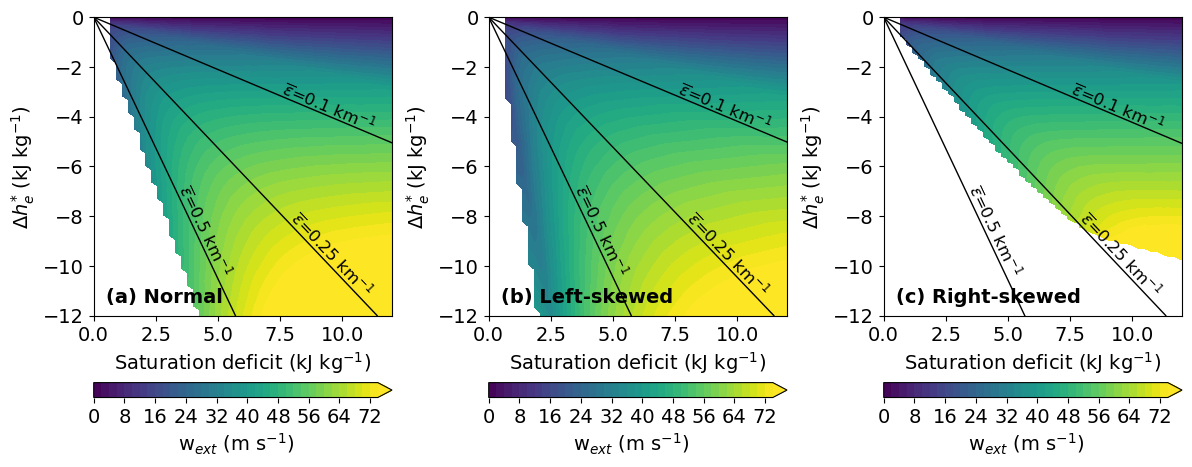

In [6]:

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(131)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_normal["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_normal["dh"])/1000
CAPEdist_list = np.array(df_normal["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_normal["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_normal["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(0,75,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(a) Normal",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(132)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_left["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_left["dh"])/1000
CAPEdist_list = np.array(df_left["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_left["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_left["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(0,75,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(b) Left-skewed",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(133)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_right["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_right["dh"])/1000
CAPEdist_list = np.array(df_right["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_right["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_right["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(0,75,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(c) Right-skewed",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')
plt.tight_layout()

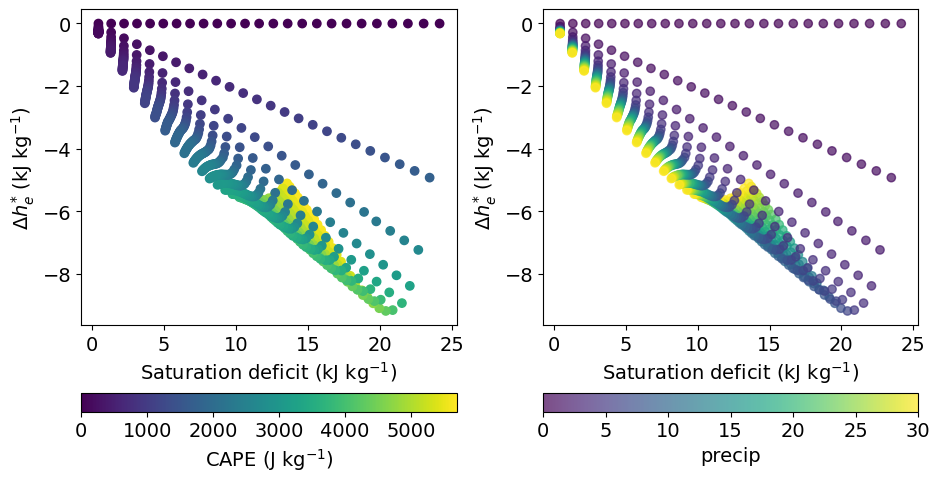

In [9]:
sat_def_arr = np.array(df_dec["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_dec["dh"])/1000
CAPEdist_list = np.array(df_dec["CAPE_ext"])
fig = plt.figure(figsize=(14,5))
ax1 = fig.add_subplot(131)
plt.scatter(sat_def_arr, dh_arr, c=CAPEdist_list)
plt.colorbar(label="CAPE (J kg$^{-1}$)",orientation="horizontal")

ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
# ax1.set_xlim(0,12)
# ax1.set_ylim(-12,0)

ax2 = fig.add_subplot(132)
P = df_dec["P"]
plt.scatter(sat_def_arr, dh_arr, c=P,alpha=0.7)
plt.colorbar(label="precip",orientation="horizontal")
ax2.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax2.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
# ax2.set_xlim(0,12)
# ax2.set_ylim(-12,0)

plt.tight_layout()

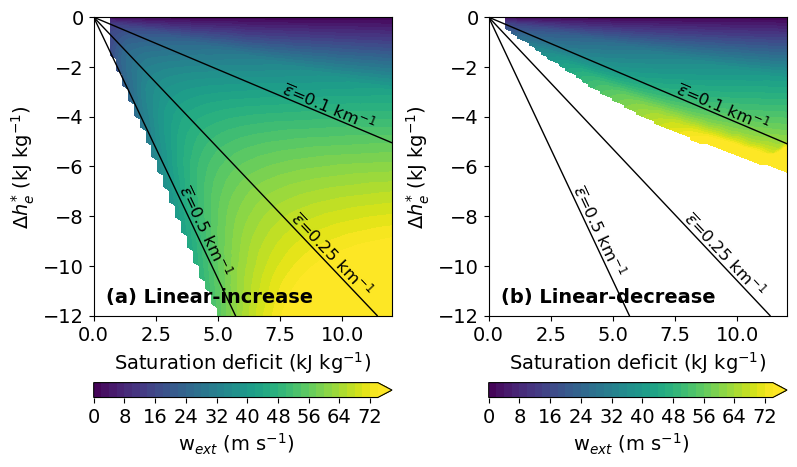

In [10]:
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(131)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_inc["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_inc["dh"])/1000
CAPEdist_list = np.array(df_inc["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_inc["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_inc["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(0,75,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(a) Linear-increase",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')

ax1 = fig.add_subplot(132)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_dec["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_dec["dh"])/1000
CAPEdist_list = np.array(df_dec["CAPE_ext"])
w_arr = np.sqrt(2*CAPEdist_list)
dz_arr = np.array(df_dec["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_dec["ent_b"])*1000
Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi,np.arange(0,75,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
ax1.text(0.5,-11.5,"(b) Linear-decrease",fontweight="bold",fontsize=14)
ax1.set_aspect('equal')
plt.tight_layout()

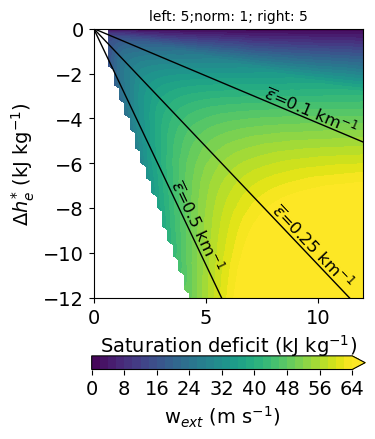

In [12]:
## mix them a little
fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(131)
## Normal distribution
## prepare arrays for plotting
sat_def_arr = np.array(df_normal["sat_def"])*const.Lv0/1000
dh_arr = np.array(df_normal["dh"])/1000

dz_arr = np.array(df_normal["dz"])/1000
dz = np.nanmean(dz_arr)
ent_b_arr = np.array(df_normal["ent_b"])*1000

## normal
CAPEdist_normal = np.array(df_normal["CAPE_ext"])
w_arr_normal = np.sqrt(2*CAPEdist_normal)
## left
CAPEdist_left = np.array(df_left["CAPE_ext"])
w_arr_left = np.sqrt(2*CAPEdist_left)

## right
CAPEdist_right = np.array(df_right["CAPE_ext"])
w_arr_right = np.sqrt(2*CAPEdist_right)

## low
# CAPEdist_low = np.array(df_low["CAPE_ext"])
# w_arr_low = np.sqrt(2*CAPEdist_low)

## high


# w_arr = (w_arr_normal + w_arr_left + w_arr_right)/3

weight_left   = 5
weight_normal = 1
weight_right  = 5



weights = np.array([ weight_left, weight_normal, weight_right]) # , weight_low

w_arr = (

    + weights[0] * w_arr_left
    + weights[1] * w_arr_normal
    + weights[2] * w_arr_right
    # + weights[4] * w_arr_low
    
) / weights.sum()

# w_arr = (
#     weight_normal * w_arr_normal
#     + weight_left * w_arr_left
#     + weight_right * w_arr_right
# )

Xi, Yi, Zi = scatter_to_contour(sat_def_arr, dh_arr, w_arr)
cf1 = ax1.contourf(Xi, Yi, Zi, levels=np.arange(0,65,2),extend="max",cmap="viridis")
fig.colorbar(cf1, ax=ax1, label=r"w$_{ext}$ (m s$^{-1}$)",orientation="horizontal")

for es,xval in zip([-0.5, -0.25,-0.1],[3.5,8.5,8.5]):
    yval = np.linspace(-12,0,20)
    xval1 = yval/(es)/dz
    
    plt.plot(xval1,yval,"k",linewidth=1)
    # slope dy/dx
    dy = yval[-1] - yval[0]
    dx = xval1[-1] - xval1[0]
    angle = np.degrees(np.arctan2(dy, dx))
    ix = np.argwhere(xval1<xval)[0][0]
    # choose a point ON the line for the label
    x_text = xval1[ix]
    y_text = yval[ix]
    if es == -0.25:
        x_text = xval1[ix+1]
        y_text = yval[ix+1]
    
    plt.text(
        x_text, y_text,
        r"$\overline{\epsilon}$"+f"={-es} km"+r"$^{-1}$",
        color="k",
        fontsize=12,
        rotation=angle+180,
        rotation_mode="anchor",
        transform_rotates_text=True,
        ha="left",
        va="bottom"
    )

ax1.set_xlim(0,12)
ax1.set_ylim(-12,0)
ax1.set_xlabel(r"Saturation deficit (kJ kg$^{-1}$)")
ax1.set_ylabel(r"$\Delta h_{e}^{*}$ (kJ kg$^{-1}$)")
# ax1.text(0.5,-11.5,f"{weight_normal}; {weight_left}; {weight_right}",fontweight="bold",fontsize=14)
ax1.set_title(f"left: {weight_left};norm: {weight_normal}; right: {weight_right}",fontsize=10)
ax1.set_aspect('equal')

In [13]:
def distribution_profile(nbins=50, skew="right"):
    '''
    Generate a distribution of plumes with different entrainment rates.
    
    '''
    x = np.linspace(0, 1, nbins)

    # Gamma parameters chosen to give a similar low-x peak
    shape = 4
    scale = 0.05

    # standard deviation for the central normal case
    sigma = np.sqrt(shape) * scale

    slope = 1
    intercept = 0.5
    
    if skew == "right":
        pdf = gamma.pdf(x, a=shape, scale=scale)
        Afac=0.0325
    elif skew == "normal":
        mu = 0.5
        pdf = norm.pdf(x, loc=mu, scale=sigma)
        Afac=0.0325
    elif skew == "left":
        # mirror the right-skewed gamma around x = 0.5
        pdf = gamma.pdf(1 - x, a=shape, scale=scale)
        Afac=0.0325
    elif skew == "strong-low-entrain":
        # exponential-like: maximum at x = 0
        shape_low = 1
        scale_low = 0.1
        pdf = gamma.pdf(x, a=shape_low, scale=scale_low)
        Afac=0.0325
    elif skew == "strong-high-entrain":
        # mirrored exponential-like distribution
        shape_high = 1
        scale_high = 0.1
        pdf = gamma.pdf(1 - x, a=shape_high, scale=scale_high)
        Afac=0.0325
    else:
        raise ValueError(
            f"Input: {skew} is not a valid option. "
            "Choose from 'right', 'normal', 'left', "
            "'strong-low-entrain', or 'strong-high-entrain'."
        )
    
    return x, pdf, Afac

In [14]:

def get_mass_pdf(P, z_b, skew_type="normal",const=const):
    x, gamma_pdf, Afac = distribution_profile(nbins=200, skew=skew_type)

    ## This is just an amplitude to control the peak.
    amp = z_b/Afac

    max_pdf_norm = np.max(gamma_pdf)

    ent_max = max_pdf_norm * (P/const.P0 / amp)
    ## We then get to know how far the entrainment rate extends 
    ent_spec = x * ent_max

    ## And we have the distribution of cloud base mass flux
    mb_spec = amp * gamma_pdf / max_pdf_norm
    arr_min = np.min(mb_spec)
    arr_max = np.max(mb_spec)

    # Apply the normalization formula
    mb_norm = (mb_spec - arr_min) / (arr_max - arr_min)
    return ent_spec*1000, mb_spec

def get_linear(P, z_b,skew_type="linear-increase",nbins=200,const=const):
    b = z_b*5

    a = 9.5e6
    ent_b = (-b +np.sqrt(b**2+2*a*(P/const.P0)) )/a
    ent_spec = np.linspace(0, ent_b, nbins)
    if skew_type == "linear-increase":
        mb_spec = a*ent_spec+b
    elif skew_type == "linear-decrease":
        mb_spec = -a*ent_spec+10*b
        
    
    return ent_spec*1000, mb_spec

([], [])

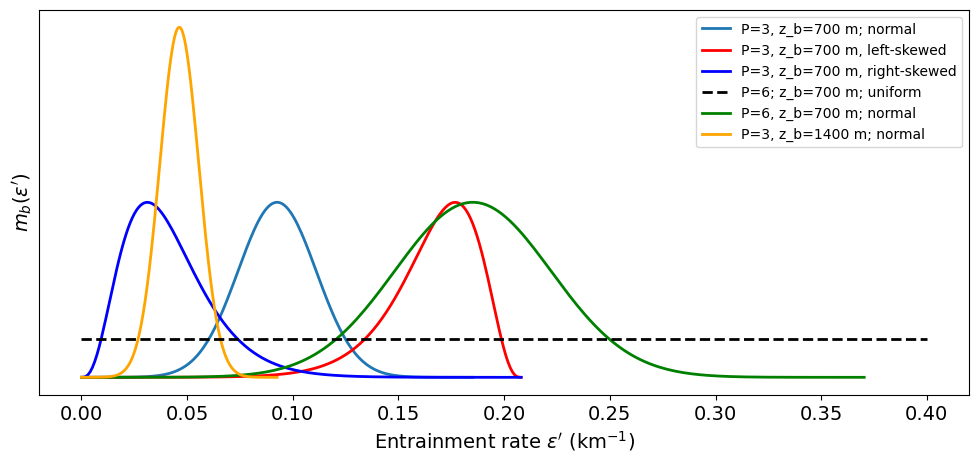

In [30]:
plt.figure(figsize=(12,5))
P=3
z_b=700
plt.plot(*get_mass_pdf(P, z_b, skew_type="normal"), label=f"P={P}, z_b={z_b} m; normal")

plt.plot(*get_mass_pdf(P, z_b, skew_type="left"), color="r", label=f"P={P}, z_b={z_b} m, left-skewed")
plt.plot(*get_mass_pdf(P, z_b, skew_type="right"), color="b", label=f"P={P}, z_b={z_b} m, right-skewed")
# plt.plot(*get_linear(P, z_b,skew_type="linear-decrease"), "r.-", label=f"P={P}, z_b={z_b} m, linear-decrease",zorder=10)
plt.hlines(y=z_b/0.15, xmin=0, xmax=0.4, color="k", linestyle="--", label=f"P=6; z_b={z_b} m; uniform",zorder=5)
# plt.plot(*get_linear(P, z_b), "r--", label=f"P={P}, z_b={z_b} m, linear-increase",linewidth=3,zorder=10)

P=6
z_b=700
plt.plot(*get_mass_pdf(P, z_b, skew_type="normal"), label=f"P={P}, z_b={z_b} m; normal",color="green")
# plt.plot(*get_linear(P, z_b), "b.-", label=f"P={P}, z_b={z_b} m, linear-increase")
# plt.plot(*get_linear(P, z_b,skew_type="linear-decrease"), "b.-", label=f"P={P}, z_b={z_b} m, linear-decrease")
# plt.plot(np.linspace(0,emax), -700*np.linspace(0,emax)+5*700+700*emax,"k--")
P=3
z_b=1400
plt.plot(*get_mass_pdf(P, z_b, skew_type="normal"), label=f"P={P}, z_b={z_b} m; normal",color="orange")
# plt.plot(*get_linear(P, z_b), ".-", label=f"P={P}, z_b={z_b} m, linear-increase",color="orange")
plt.legend(fontsize=10)
plt.xlabel(r"Entrainment rate $\epsilon'$ (km$^{-1}$)")
plt.ylabel(r"$m_b(\epsilon')$")
# plt.ylim(2000, 12000)
plt.yticks([])
# For the same total cloud-base mass flux, a deeper boundary layer concentrates that mass flux into a narrower range of lower entrainment rates. 

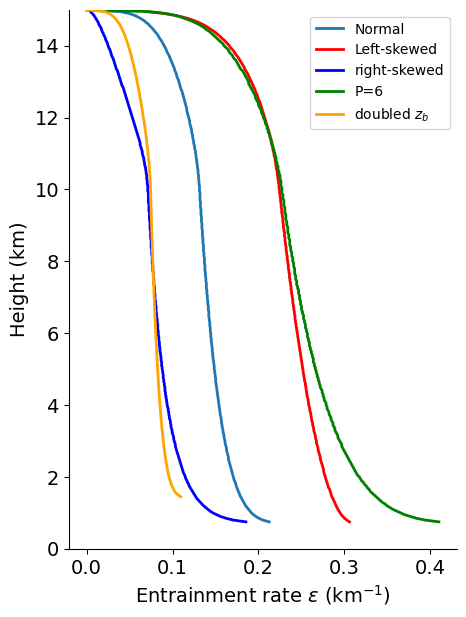

In [32]:
fig = plt.figure(figsize=(5,7))
ax1 = fig.add_subplot(111)
P=3
z_b = 700

df_normal_v = spectral_plume_skew(P=P, z_lcl = z_b, nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="normal")[0]
plt.plot(df_normal_v["ent"][df_normal_v["z"]>z_b]*1000,df_normal_v["z"][df_normal_v["z"]>z_b]/1000,label="Normal")

df_left_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="left")[0]
plt.plot(df_left_v["ent"][df_left_v["ent"]>0]*1000,df_left_v["z"][df_left_v["ent"]>0]/1000,label="Left-skewed",color="r")

# df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-increase")[0]
# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label="P=3; linear-increase",color="r",linestyle="--")

# df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-decrease")[0]
# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label="linear-decrease",color="b",linestyle="--")


df_right_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="right")[0]
plt.plot(df_right_v["ent"][df_right_v["ent"]>0]*1000,df_right_v["z"][df_right_v["ent"]>0]/1000,label="right-skewed",color="b")

P = 6
z_b = 700

df_normal_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="normal")[0]
plt.plot(df_normal_v["ent"][df_normal_v["z"]>z_b]*1000,df_normal_v["z"][df_normal_v["z"]>z_b]/1000,label=f"P=6", color="green")
# df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-increase")[0]

# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label="P=6; linear-increase",color="b",linestyle="--")
# plt.plot(df_increase_v["ent_uniform"][df_increase_v["ent_uniform"]>0]*1000,df_increase_v["z"][df_increase_v["ent_uniform"]>0]/1000,label="P=6; uniform",color="k",linestyle="-")


P = 3
z_b = 1400

df_normal_v = spectral_plume_skew(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="normal")[0]
plt.plot(df_normal_v["ent"][df_normal_v["z"]>z_b]*1000,df_normal_v["z"][df_normal_v["z"]>z_b]/1000,label=r"doubled $z_b$", color="orange")
# df_increase_v = spectral_plume_linear(P=P, z_lcl = z_b,nbins=500, get_plane=False, plotting=False, save_data=False,skew_type="linear-increase")[0]
# plt.plot(df_increase_v["ent"][df_increase_v["ent"]>0]*1000,df_increase_v["z"][df_increase_v["ent"]>0]/1000,label=r"Doubled $z_b$; linear-increase ",color="orange",linestyle="--")

plt.legend(loc="upper right",fontsize=10)
ax1.set_xlabel(r"Entrainment rate $\epsilon$ (km$^{-1}$)")
ax1.set_ylabel("Height (km)")
plt.ylim(0,15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

In [17]:

ent0 = 0.15/z_b
b = 0.01

a = 2 * ( P / const.P0 - b * ent0) / ent0**2


174222035.55555558

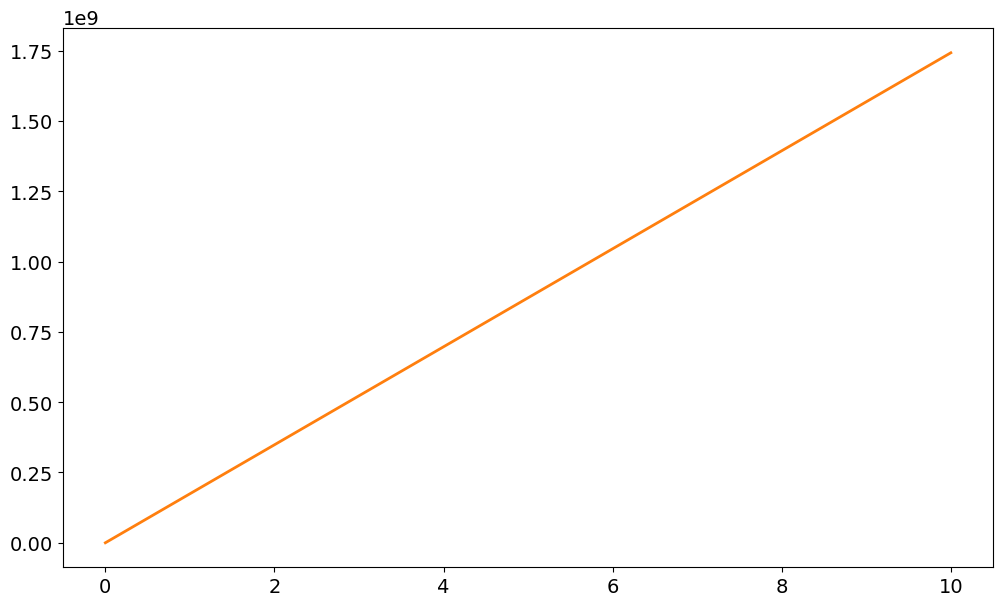

In [20]:
plt.plot(np.linspace(0,ent0,100), a*np.linspace(0,ent0,100) + b)
plt.plot(np.linspace(0,10,100), a*np.linspace(0,10,100) + b)